# Phase Analyzer

Analyzes the phase patterns, modelled as genetic instances, after optimization 

In [374]:
# Functions to import

import numpy as np 
import scipy as sp
import pygad
import yaml 
from yaml import Loader 

from scipy.fft import fft2, fftfreq, ifft2, fftshift, ifftshift
from optical_functions import LG, propFF, cart2pol, oamModes, output_chan, setKnotType, output_chan_symmetric

import matplotlib.pyplot as plt 

from diffractsim import cm, mm, um 
import os

# Function which plots the phase and intensity of the field

'''
Jointly plots the intensity and phase patterns of the complex field.

Ex - complex 2D array -  field
'''

def TotInt(Ex):
    fig, ax =  plt.subplots(1,2,figsize=(10,10))
    ax[0].set_title('Intensity')
    intensity = ax[0].imshow(abs(Ex)**2,cmap="gist_gray")
    ax[0].axis('off')
    cbar=fig.colorbar(intensity, fraction=0.05, pad=0.04, ax=ax[0])
    
    
    ax[1].set_title('Phase')
    phase = ax[1].imshow(np.angle(Ex), cmap="hsv", interpolation='nearest')
    ax[1].axis('off')
    cbar=fig.colorbar(phase,fraction=0.05, pad=0.04, ax=ax[1])
    plt.show()


# Create field & modes of interest following yaml configuration

In [375]:
stream = open(f"configs/ga0.yaml", 'r')
cnfg = yaml.load(stream, Loader=Loader)

N = cnfg['dim']
num_of_output_chans = cnfg['num_output_chans']
output_chan_width = cnfg['output_chan_width'] * mm # in mm 
num_of_phase_maps = cnfg['num_maps']
instance_name = cnfg['ga_instance'] # directory name of best phases

# Some parameters specifying the LG modes

LG_modes = cnfg['LG_modes']
w0 = cnfg['w0'] * mm # in mm!!

isKnot = cnfg['isKnot']
knotType = cnfg['knotType']
shapeParams = cnfg['shapeParams']
fourier_lens = cnfg['fourier_length']*cm # fourier length of both lens in cm
GFilterStrength=cnfg['gauss_filter_sigma']
channel_seperation = cnfg['channel_sep']

# Define the coordinate space 

la = 0.78*um
k=(2*np.pi)/la  # [m^-1] wavenumber    
N=128 # [Number of points per dimension]
maxx = 20*um*N  # Full length of the numerical window (m)

# Space definition 
dx = maxx/N
dy = maxx/N 

#okay let's just say h here is dx or dy for now WLOG (WITH ... loss of generality)

h = dx
X = dx*(np.arange(N) - N //2)
Y = dy*(np.arange(N) - N //2)

xx,yy=np.meshgrid(X,Y);
r, phi= cart2pol(xx,yy)

''' 
Create the OAM beams that we need to sort 
'''
# Now create a list containing 'oamMode' objects 

list_of_OAMs = []
output_chans = output_chan_symmetric(X,Y,output_chan_width, maxx,num_of_output_chans, chan_sep=0.9)

if(isKnot):
    for ii in range(len(knotType)):
        list_of_OAMs.append(oamModes(setKnotType(r, phi, w0, knotType[ii], shapeParams[ii]), output_chans[ii]))
        
else:
    for ii in range(len(LG_modes)):
        list_of_OAMs.append(oamModes(LG(r, phi, LG_modes[ii][0], LG_modes[ii][1], w0,h,0,k), output_chans[ii]))


Plot output channels

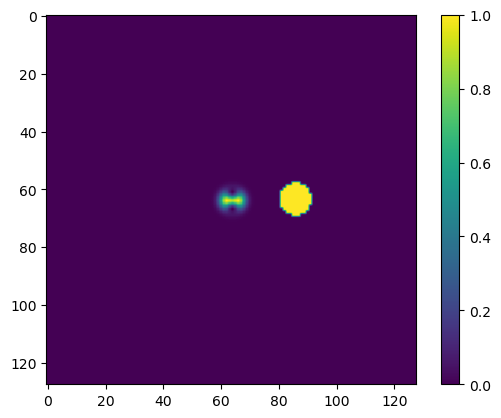

In [376]:
field = list_of_OAMs[1].oamBeam + list_of_OAMs[0].oamBeam
field = field/np.max(np.abs(field))

plt.imshow(np.abs(output_chans[1])**2 + np.abs(field)**2)
plt.colorbar()

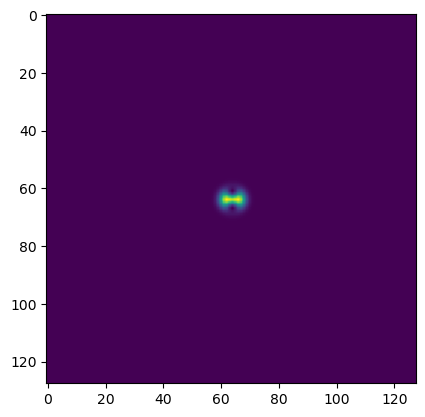

In [377]:
field_fft = fftshift(fft2(field))
field_ifft = ifft2(ifftshift(field_fft))

plt.imshow(np.abs(field_ifft)**2)

In [378]:
np.exp(1j*2*np.pi)

(1-2.4492935982947064e-16j)

In the paper by Fickler, they consider phase holograms ... "that modulate the beam by atleast 40 x 40 pixels" 

In [379]:
count_x = 0
count_y = 0

# Here, we increment count_x because we are iterating in the horizontal direction 
for ii in range(N):
    for jj in range(N): 
        if(np.abs(field[ii,jj])**2 > 1e-10):
            count_x += 1

        
# Here, we increment count_y because we are iterating in the vertical direction 

for jj in range(N):
    for ii in range(N):
        if(np.abs(field[ii,jj])**2 > 1e-10):
            count_y += 1

    

In [380]:
count_x

553

Load genetic Instance

In [381]:
import pickle

#instance_name = 'knots_smaller_oneMap'

with open(f"best_phases/{instance_name}.pkl", 'rb') as file:
     phase_out = pickle.load(file)

In [382]:
np.max(phase_out)

9.90385652793461

Compute phase screens and plot them 

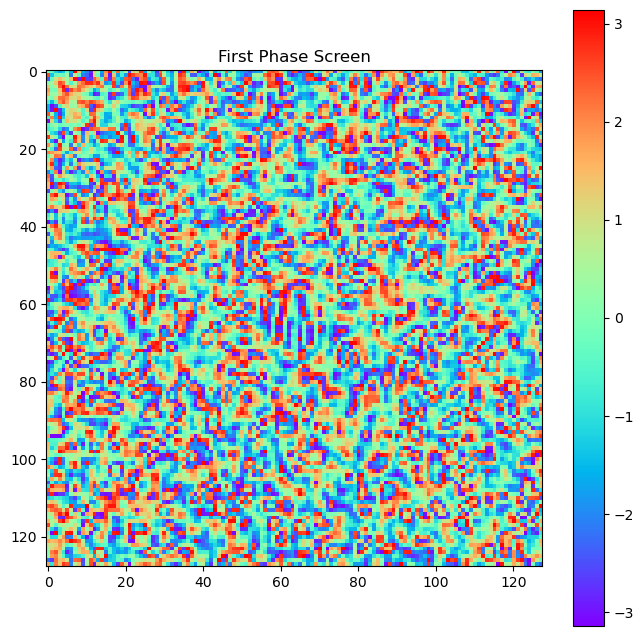

In [383]:
phase_maps = np.empty((num_of_phase_maps, N, N), dtype=complex)

# Compute phase screens and plot them 
for ii in range(num_of_phase_maps):
    phase_maps[ii]= np.exp(1j*phase_out[ii])

#phaseScreenDos = np.exp(1j*phase_out[1,:,:])

fig, ax = plt.subplots(1,1, figsize=(8,8))

first = ax.imshow(np.angle(phase_maps[0]), cmap='rainbow')
ax.set_title("First Phase Screen")
c1 = fig.colorbar(first, ax=ax)

plt.show()

In [384]:
np.min(np.angle(phase_out))

0.0

Let's also consider an actual hologram here

In [385]:
print(instance_name)

knots_fourierTrans


In [386]:
# This function generates phase gratings in reminisce of OAM gratings 

def OAMWithGratings(l,rows,cols,xoffset,yoffset,a):
    
    crow, ccol = int(rows / 2)+xoffset, int(cols / 2)+yoffset
    mask = np.zeros((rows,cols)) +0j
    fx = 10.0
    fy = 0.0
    phi = np.zeros((rows,cols))+0j

    for i in range (rows):
        for j in range (cols):
            
            x = i - crow
            y = j - ccol
            alpha = l*np.arctan2(x,y) + 2*np.pi*10*y/128
            g = a[0] + a[1]*np.cos(2*alpha)  + a[2]*np.cos(3*alpha) + a[3]*np.cos(4*alpha)
                  #g = 1/4*(1 + np.cos(alpha) + np.cos(2*alpha) +  np.cos(3*alpha)+np.cos(4*alpha))
                  #g = np.mod(alpha,2*np.pi)
            mask[i,j] = g
        
    return(mask)

test_mask = OAMWithGratings(1,N,N,0,0,[1,1,1,1])

Compute the propagation for each mode

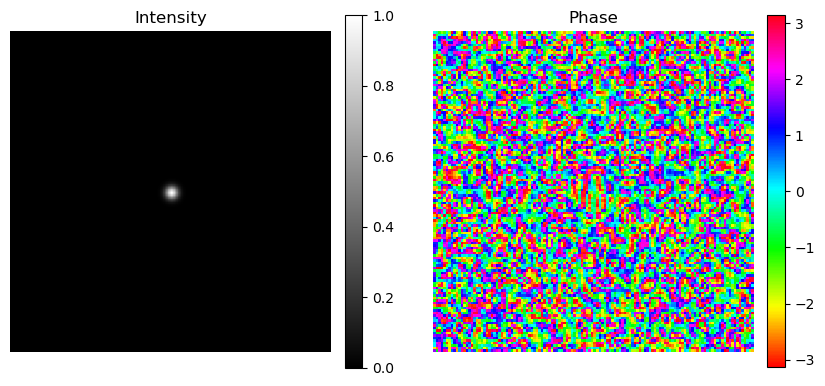

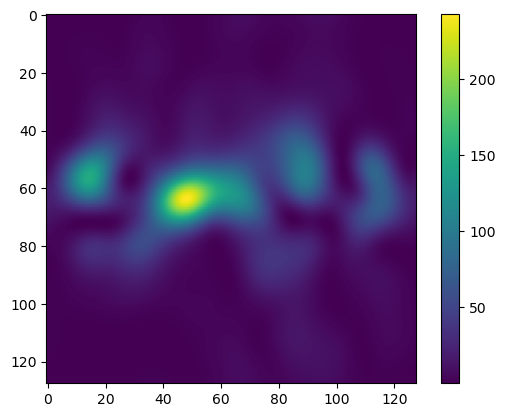

In [414]:
from scipy.fft import ifft2, ifftshift, fft2, fftshift

# Let's pick an LG beam to analyze

mode_num = 0

field = list_of_OAMs[mode_num].oamBeam 
field = field/np.max(np.abs(field))

# modulate the field by the first phase map 

field_mod_1 = field*phase_maps[0]

TotInt(field_mod_1)

# let's simulate the propagation of the lens

#field_lens, _ = propFF(field_mod_1,maxx,la,fourier_lens)
field_lens = fftshift(fft2(field_mod_1))
#field_lens = field_lens/np.max(np.abs(field_lens))

# compute the field intensity 

final_field_int = np.abs(field_lens)**2
plt.imshow(final_field_int)
plt.colorbar()

Simulating the second phase map

In [373]:
# modulate the field by the second phase map 

field_mod_2 = field_lens*phase_maps[1]

# simulate the lens field again. This is the final field. 

#field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
field_lens_2 = ifft2(ifftshift(field_mod_2))

plt.imshow(abs(field_lens_2)**2)

IndexError: index 1 is out of bounds for axis 0 with size 1

# Compute the normalized sorting probability 

TypeError: Invalid shape (2, 128, 128) for image data

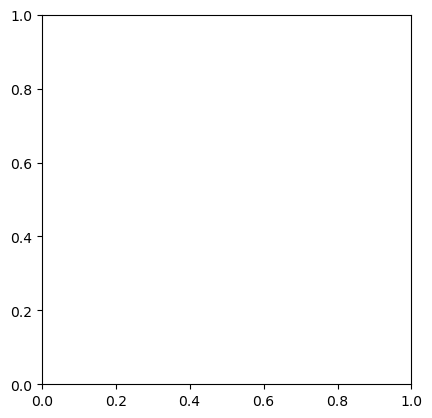

In [405]:
sorting_performance = 0
correct_chans_list = []
total_chans_list = []

simulateLens = False

 # Now, this is the fitness parameter 

for ii in range(len(list_of_OAMs)):

    # Define initial OAM field and correct output channel 

    field = list_of_OAMs[ii].oamBeam 

    # Do a rough normalization on the incident field 

    field = field/np.max(np.abs(field))

    # modulate the field by the first phase map 

    field_mod_1 = field*phase_maps[0]

    # let's simulate the propagation of the lens
    if (simulateLens):
        field_lens, _ = propFF(field_mod_1,maxx,la,fourier_lens)
    else: # Take the fourier transform 
        field_lens = fftshift(fft2(field_mod_1))

    # What happens next depends on whether we have one or two phase maps

    if(num_of_phase_maps==1):
        # Compute the field intensity 
        final_field = field_lens
    else:
        # modulate the field by the second phase map 
        field_mod_2 = field_lens*phase_maps[1]
        # simulate the lens field again. This is the final field. 
        if (simulateLens):
            field_lens_2, _ = propFF(field_mod_2, maxx, la, fourier_lens)
        else: 
            field_lens_2 = ifft2(ifftshift(field_mod_2))
        # compute the field intensity 
        field_lens_2 = field_lens_2/np.max(np.abs(field_lens_2))

        final_field = field_lens_2
        #final_field_int = np.abs(field_lens_2)**2
        

    # Define full set of indices, as you would summing through a for loop
    full_index = np.arange(len(output_chans))   
    # Delete ii from the list of full_index, creating a new temporary array
    temp_index = np.delete(full_index, ii)
    # Sum up the "incorrect" channels 
    incorrect_chans = 0
    total_chans = 0
    for ind in temp_index:
        incorrect_chans += field_in_pupil
    # Now, evaluate the sorting performance 
    correct_chans = (np.abs(final_field)**2)*output_chans[ii]
    correct_chans_list.append(correct_chans)
    sorting_performance += correct_chans - incorrect_chans
    total_chans = correct_chans + incorrect_chans
    total_chans_list.append(total_chans)
    
total_chans_list = np.array(total_chans_list)
correct_chans_list = np.array(correct_chans_list)

Now we compute the normalized sorting probability

0


C:\Users\tjaou104\AppData\Local\Temp\ipykernel_24708\1407221187.py:3: RuntimeWarning: invalid value encountered in divide
  sorting_prob = correct_chans_list[ii]/(total_chans_list[ii])


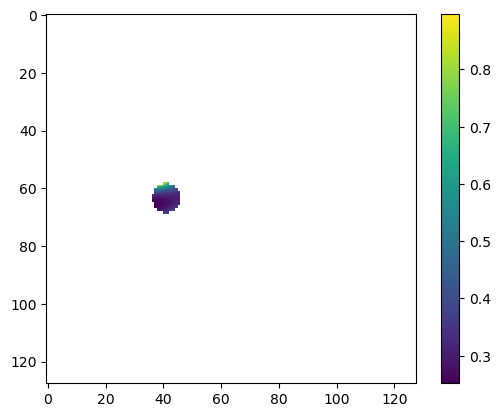

0.37645051126333906
1


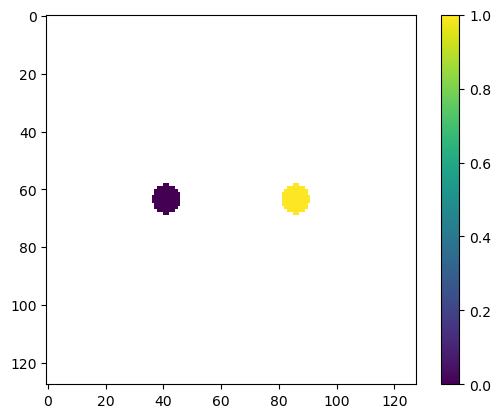

0.5


In [413]:
for ii in range(len(list_of_OAMs)):
    print(ii)
    sorting_prob = correct_chans_list[ii]/(total_chans_list[ii])
    plt.imshow(sorting_prob)
    plt.colorbar()
    plt.show()
    print(np.nanmean(sorting_prob))
    